# 🚢 Project 1 — Titanic Dataset Analysis
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Tasks:** Data Cleaning → Statistical Analysis → Visualization

---

## Importing Libraries

In [2]:
# ── Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("All libraries loaded ✓")

All libraries loaded ✓


## 1. Dataset Creation & Loading

In [3]:
# Build the Titanic dataset (reproducible seed)
np.random.seed(42)
n = 891

pclass = np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55])
sex    = np.random.choice(['male', 'female'], n, p=[0.647, 0.353])

age = np.where(pclass==1, np.clip(np.random.normal(39,14,n),1,80),
      np.where(pclass==2, np.clip(np.random.normal(30,13,n),1,70),
                          np.clip(np.random.normal(25,12,n),1,65)))

fare = np.where(pclass==1, np.clip(np.random.exponential(60,n)+10,10,512),
       np.where(pclass==2, np.clip(np.random.exponential(15,n)+8,8,73),
                           np.clip(np.random.exponential(8,n)+4,4,69)))

sibsp    = np.random.choice([0,1,2,3,4,5], n, p=[0.68,0.23,0.05,0.02,0.01,0.01])
parch    = np.random.choice([0,1,2,3,4,5], n, p=[0.76,0.13,0.09,0.01,0.005,0.005])
embarked = np.random.choice(['S','C','Q'], n, p=[0.724,0.188,0.088])
emb_town = {'S':'Southampton','C':'Cherbourg','Q':'Queenstown'}

# Survival probabilities (women & upper class survive more)
surv_prob = np.where(sex=='female',
    np.where(pclass==1,0.97,np.where(pclass==2,0.92,0.50)),
    np.where(pclass==1,0.37,np.where(pclass==2,0.16,0.14)))
survived = (np.random.random(n) < surv_prob).astype(int)

# Introduce 20% missing ages
miss = np.random.random(n) < 0.20
age_nan = age.astype(float); age_nan[miss] = np.nan

df_raw = pd.DataFrame({
    'survived': survived, 'pclass': pclass, 'sex': sex,
    'age': age_nan, 'sibsp': sibsp, 'parch': parch,
    'fare': fare, 'embarked': embarked,
    'embark_town': [emb_town[e] for e in embarked]
})

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (891, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,embark_town
0,1,2,female,NaN,0,0,11.992536,S,Southampton
1,1,3,female,3.978054,0,0,4.322889,S,Southampton
2,0,3,male,20.320916,2,0,8.127225,S,Southampton
3,1,3,female,26.896642,1,0,12.379262,S,Southampton
4,1,1,male,57.224378,0,1,72.763972,C,Cherbourg


## 2. Data Cleaning & Missing Values

In [4]:
# Missing values BEFORE cleaning
print("=== Missing Values (before) ===")
missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Count': missing, 'Percent (%)': pct})[missing > 0]

=== Missing Values (before) ===


,Count,Percent (%)
age,187,20.99


In [5]:
# --- Cleaning ---
df = df_raw.copy()

# Fill age with median per class (preserves class-age relationship)
df['age'] = df.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

# Engineered feature
df['family_size'] = df['sibsp'] + df['parch']

print("=== Missing Values (after) ===")
after = df.isnull().sum()
print("None!" if after.sum() == 0 else after[after > 0])
print(f"\nFinal shape: {df.shape}")

=== Missing Values (after) ===
None!

Final shape: (891, 10)


## 3. Statistical Analysis

In [6]:
# Descriptive statistics
print("=== Descriptive Statistics ===")
df[['age','fare','sibsp','parch','family_size']].describe().round(2)

=== Descriptive Statistics ===


,age,fare,sibsp,parch,family_size
count,891.00,891.00,891.00,891.00,891.00
mean,29.67,29.27,0.42,0.33,0.76
std,12.57,42.61,0.82,0.73,1.14
min,1.00,4.01,0.00,0.00,0.00
25%,22.87,8.56,0.00,0.00,0.00
50%,28.73,14.36,0.00,0.00,0.00
75%,38.88,28.03,1.00,0.00,1.00
max,74.81,413.17,5.00,5.00,8.00


In [7]:
# Survival breakdown
survival_rate = df['survived'].mean() * 100
print(f"Overall Survival Rate : {survival_rate:.1f}%")
print(f"Survived              : {df['survived'].sum()}")
print(f"Did Not Survive       : {(df['survived']==0).sum()}")

print("\n--- By Gender ---")
print(df.groupby('sex')['survived'].agg(['sum','mean'])
        .rename(columns={'sum':'Count','mean':'Rate'})
        .assign(Rate=lambda x: (x['Rate']*100).round(1)))

print("\n--- By Class ---")
print(df.groupby('pclass')['survived'].agg(['sum','mean'])
        .rename(columns={'sum':'Count','mean':'Rate'})
        .assign(Rate=lambda x: (x['Rate']*100).round(1)))

Overall Survival Rate : 37.1%
Survived              : 331
Did Not Survive       : 560

--- By Gender ---
        Count  Rate
sex                
female    221  67.4
male      110  19.5

--- By Class ---
        Count  Rate
pclass             
1         141  61.6
2          67  37.9
3         123  25.4


## 4. Visualizations — Overview Dashboard

In [10]:
# Style
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22', 'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9', 'axes.titlecolor': '#f0f6fc',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d', 'grid.linewidth': 0.8,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
ACCENT,RED,GREEN,PURPLE,ORANGE = '#58a6ff','#ff7b72','#3fb950','#d2a8ff','#ffa657'
w = 0.35
print("Style configured ✓")

Style configured ✓


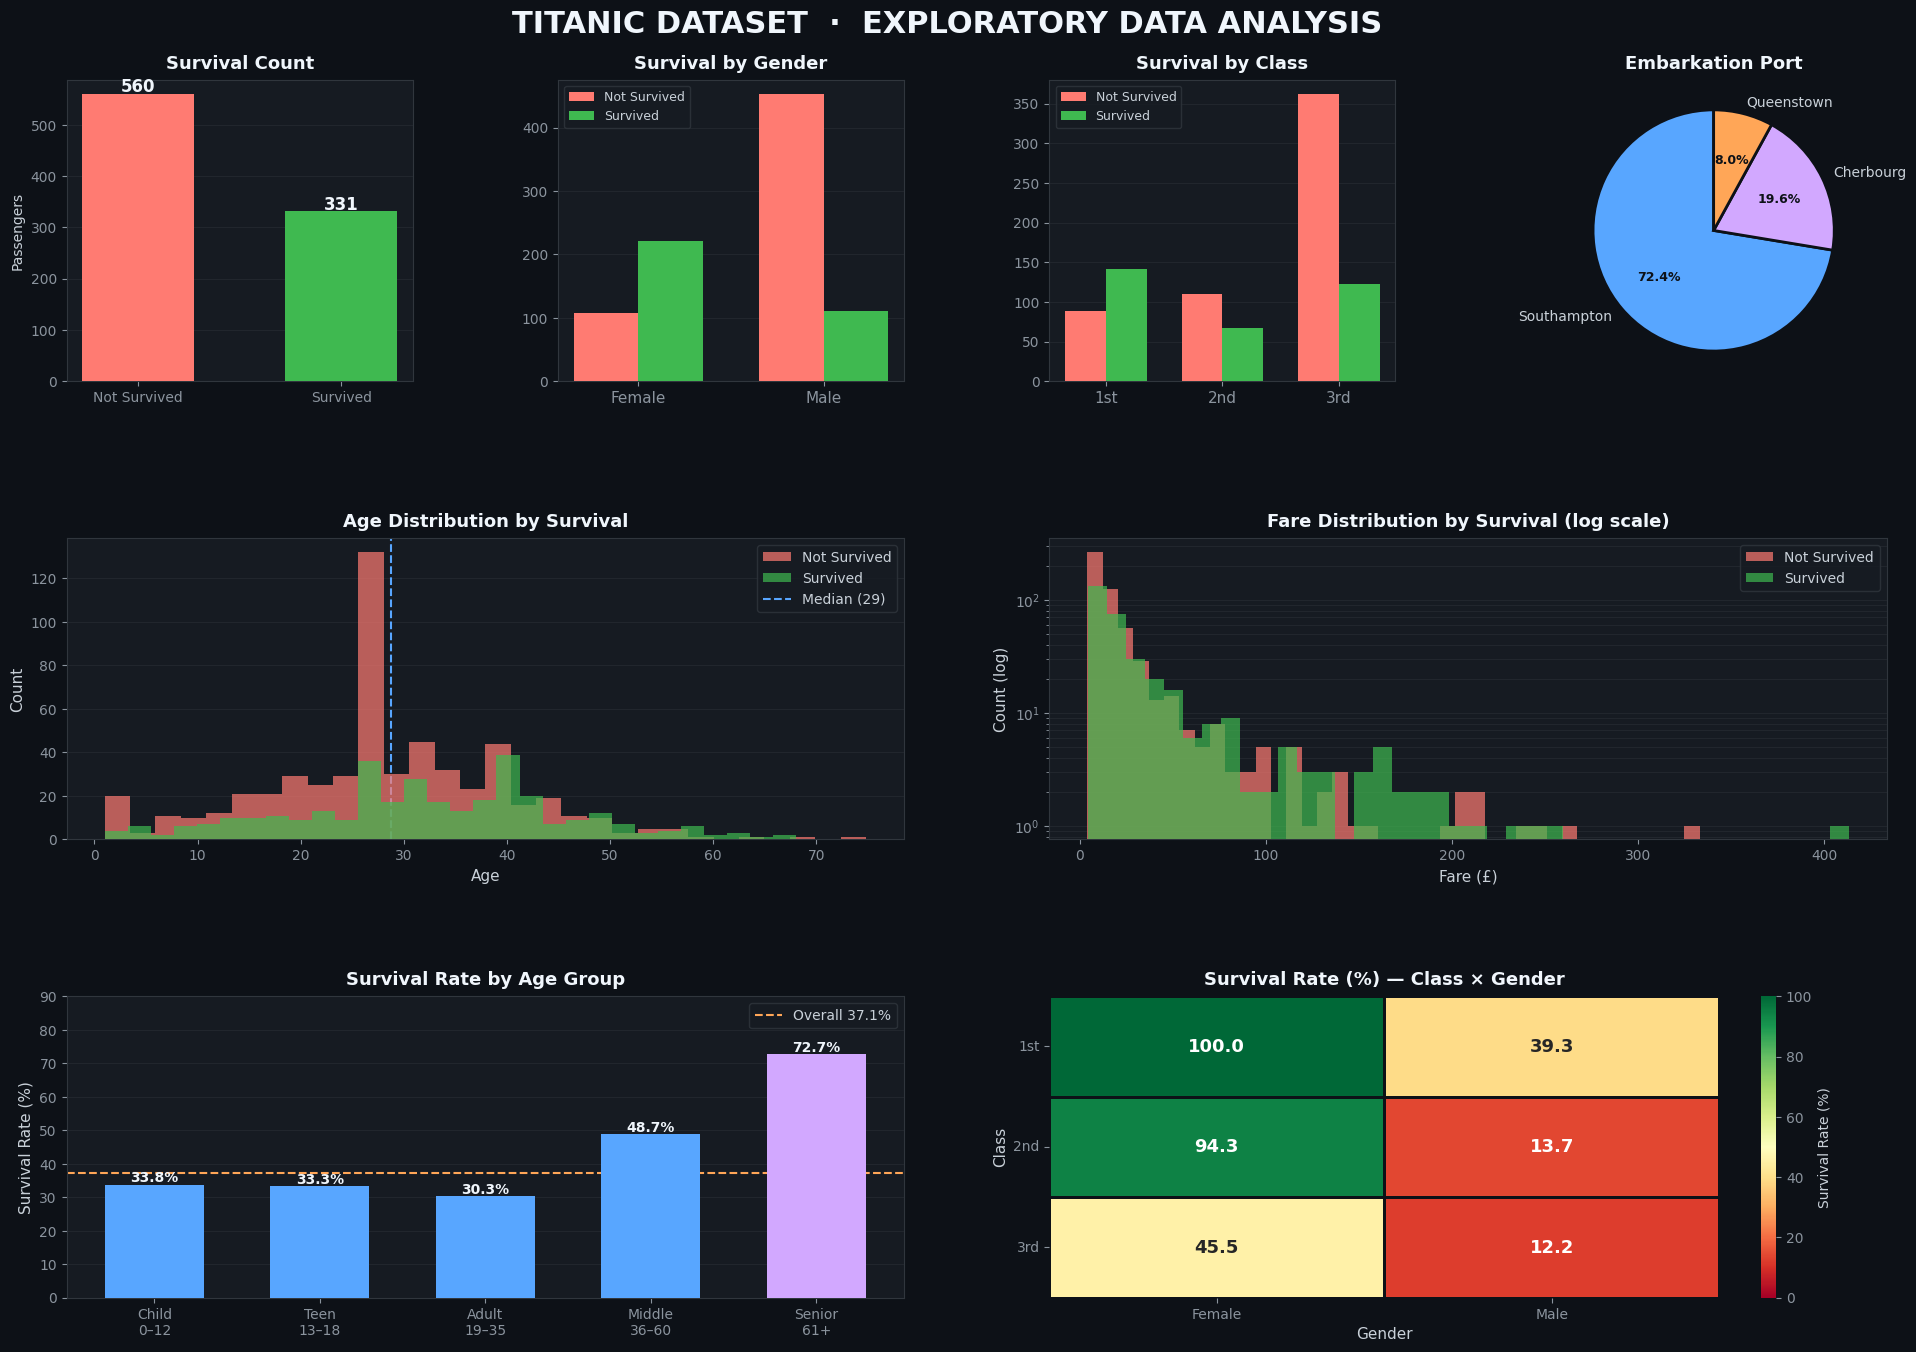

In [11]:
fig = plt.figure(figsize=(20,14), facecolor='#0d1117')
fig.suptitle('TITANIC DATASET  ·  EXPLORATORY DATA ANALYSIS',
             fontsize=22, fontweight='bold', color='#f0f6fc', y=0.99)
gs = gridspec.GridSpec(3,4,figure=fig,hspace=0.52,wspace=0.42,top=0.94,bottom=0.07,left=0.06,right=0.97)

# (1) Survival count
ax = fig.add_subplot(gs[0,0])
sc = df['survived'].value_counts().sort_index()
bars = ax.bar(['Not Survived','Survived'], sc.values, color=[RED,GREEN], width=0.55, edgecolor='none', zorder=3)
for b,v in zip(bars,sc.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+4, str(v), ha='center', fontsize=12, fontweight='bold', color='#f0f6fc')
ax.set_title('Survival Count',fontsize=13,fontweight='bold',pad=8)
ax.set_ylabel('Passengers',fontsize=10); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# (2) By gender
ax = fig.add_subplot(gs[0,1])
g2 = df.groupby(['sex','survived']).size().unstack(fill_value=0); g2.columns=['No','Yes']
x = np.arange(2)
ax.bar(x-w/2,g2['No'],w,color=RED,label='Not Survived',edgecolor='none',zorder=3)
ax.bar(x+w/2,g2['Yes'],w,color=GREEN,label='Survived',edgecolor='none',zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['Female','Male'],fontsize=11)
ax.set_title('Survival by Gender',fontsize=13,fontweight='bold',pad=8)
ax.legend(fontsize=9); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# (3) By class
ax = fig.add_subplot(gs[0,2])
gc = df.groupby(['pclass','survived']).size().unstack(fill_value=0); gc.columns=['No','Yes']
x = np.arange(3)
ax.bar(x-w/2,gc['No'],w,color=RED,label='Not Survived',edgecolor='none',zorder=3)
ax.bar(x+w/2,gc['Yes'],w,color=GREEN,label='Survived',edgecolor='none',zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['1st','2nd','3rd'],fontsize=11)
ax.set_title('Survival by Class',fontsize=13,fontweight='bold',pad=8)
ax.legend(fontsize=9); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# (4) Embarkation pie
ax = fig.add_subplot(gs[0,3])
emb = df['embark_town'].value_counts()
_,texts,ats = ax.pie(emb.values,labels=emb.index,autopct='%1.1f%%',
    colors=[ACCENT,PURPLE,ORANGE],startangle=90,wedgeprops=dict(edgecolor='#0d1117',linewidth=2))
for t in texts: t.set_color('#c9d1d9'); t.set_fontsize(10)
for at in ats:  at.set_color('#0d1117'); at.set_fontsize(9); at.set_fontweight('bold')
ax.set_title('Embarkation Port',fontsize=13,fontweight='bold',pad=8)

# (5) Age histogram
ax = fig.add_subplot(gs[1,0:2])
ax.hist(df[df['survived']==0]['age'],bins=30,alpha=0.7,color=RED,label='Not Survived',edgecolor='none',zorder=3)
ax.hist(df[df['survived']==1]['age'],bins=30,alpha=0.7,color=GREEN,label='Survived',edgecolor='none',zorder=3)
ax.axvline(df['age'].median(),color=ACCENT,ls='--',lw=1.5,label=f'Median ({df["age"].median():.0f})')
ax.set_title('Age Distribution by Survival',fontsize=13,fontweight='bold',pad=8)
ax.set_xlabel('Age',fontsize=11); ax.set_ylabel('Count',fontsize=11)
ax.legend(fontsize=10); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# (6) Fare histogram (log)
ax = fig.add_subplot(gs[1,2:4])
ax.hist(df[df['survived']==0]['fare'],bins=40,alpha=0.7,color=RED,label='Not Survived',edgecolor='none',zorder=3)
ax.hist(df[df['survived']==1]['fare'],bins=40,alpha=0.7,color=GREEN,label='Survived',edgecolor='none',zorder=3)
ax.set_yscale('log')
ax.set_title('Fare Distribution by Survival (log scale)',fontsize=13,fontweight='bold',pad=8)
ax.set_xlabel('Fare (£)',fontsize=11); ax.set_ylabel('Count (log)',fontsize=11)
ax.legend(fontsize=10); ax.yaxis.grid(True,which='both',zorder=0); ax.set_axisbelow(True)

# (7) Age group survival rate
ax = fig.add_subplot(gs[2,0:2])
df['age_group'] = pd.cut(df['age'],bins=[0,12,18,35,60,100],
    labels=['Child\n0–12','Teen\n13–18','Adult\n19–35','Middle\n36–60','Senior\n61+'])
ag = df.groupby('age_group',observed=False)['survived'].mean()*100
bc = [PURPLE if v==ag.max() else ACCENT for v in ag.values]
bars7 = ax.bar(ag.index,ag.values,color=bc,edgecolor='none',zorder=3,width=0.6)
for b,v in zip(bars7,ag.values):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.8,f'{v:.1f}%',ha='center',fontsize=10,fontweight='bold',color='#f0f6fc')
ax.axhline(survival_rate,color=ORANGE,ls='--',lw=1.5,label=f'Overall {survival_rate:.1f}%')
ax.set_title('Survival Rate by Age Group',fontsize=13,fontweight='bold',pad=8)
ax.set_ylabel('Survival Rate (%)',fontsize=11); ax.set_ylim(0,90)
ax.legend(fontsize=10); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# (8) Survival heatmap class × gender
ax = fig.add_subplot(gs[2,2:4])
pivot = df.pivot_table('survived',index='pclass',columns='sex',aggfunc='mean')*100
sns.heatmap(pivot,annot=True,fmt='.1f',cmap='RdYlGn',center=50,
            linewidths=2,linecolor='#0d1117',annot_kws={'size':13,'weight':'bold'},
            ax=ax,cbar_kws={'label':'Survival Rate (%)'},vmin=0,vmax=100)
ax.set_title('Survival Rate (%) — Class × Gender',fontsize=13,fontweight='bold',pad=8)
ax.set_xlabel('Gender',fontsize=11); ax.set_ylabel('Class',fontsize=11)
ax.set_yticklabels(['1st','2nd','3rd'],rotation=0)
ax.set_xticklabels(['Female','Male'],rotation=0)

plt.show()

## 5. Correlation Analysis & Advanced Distributions

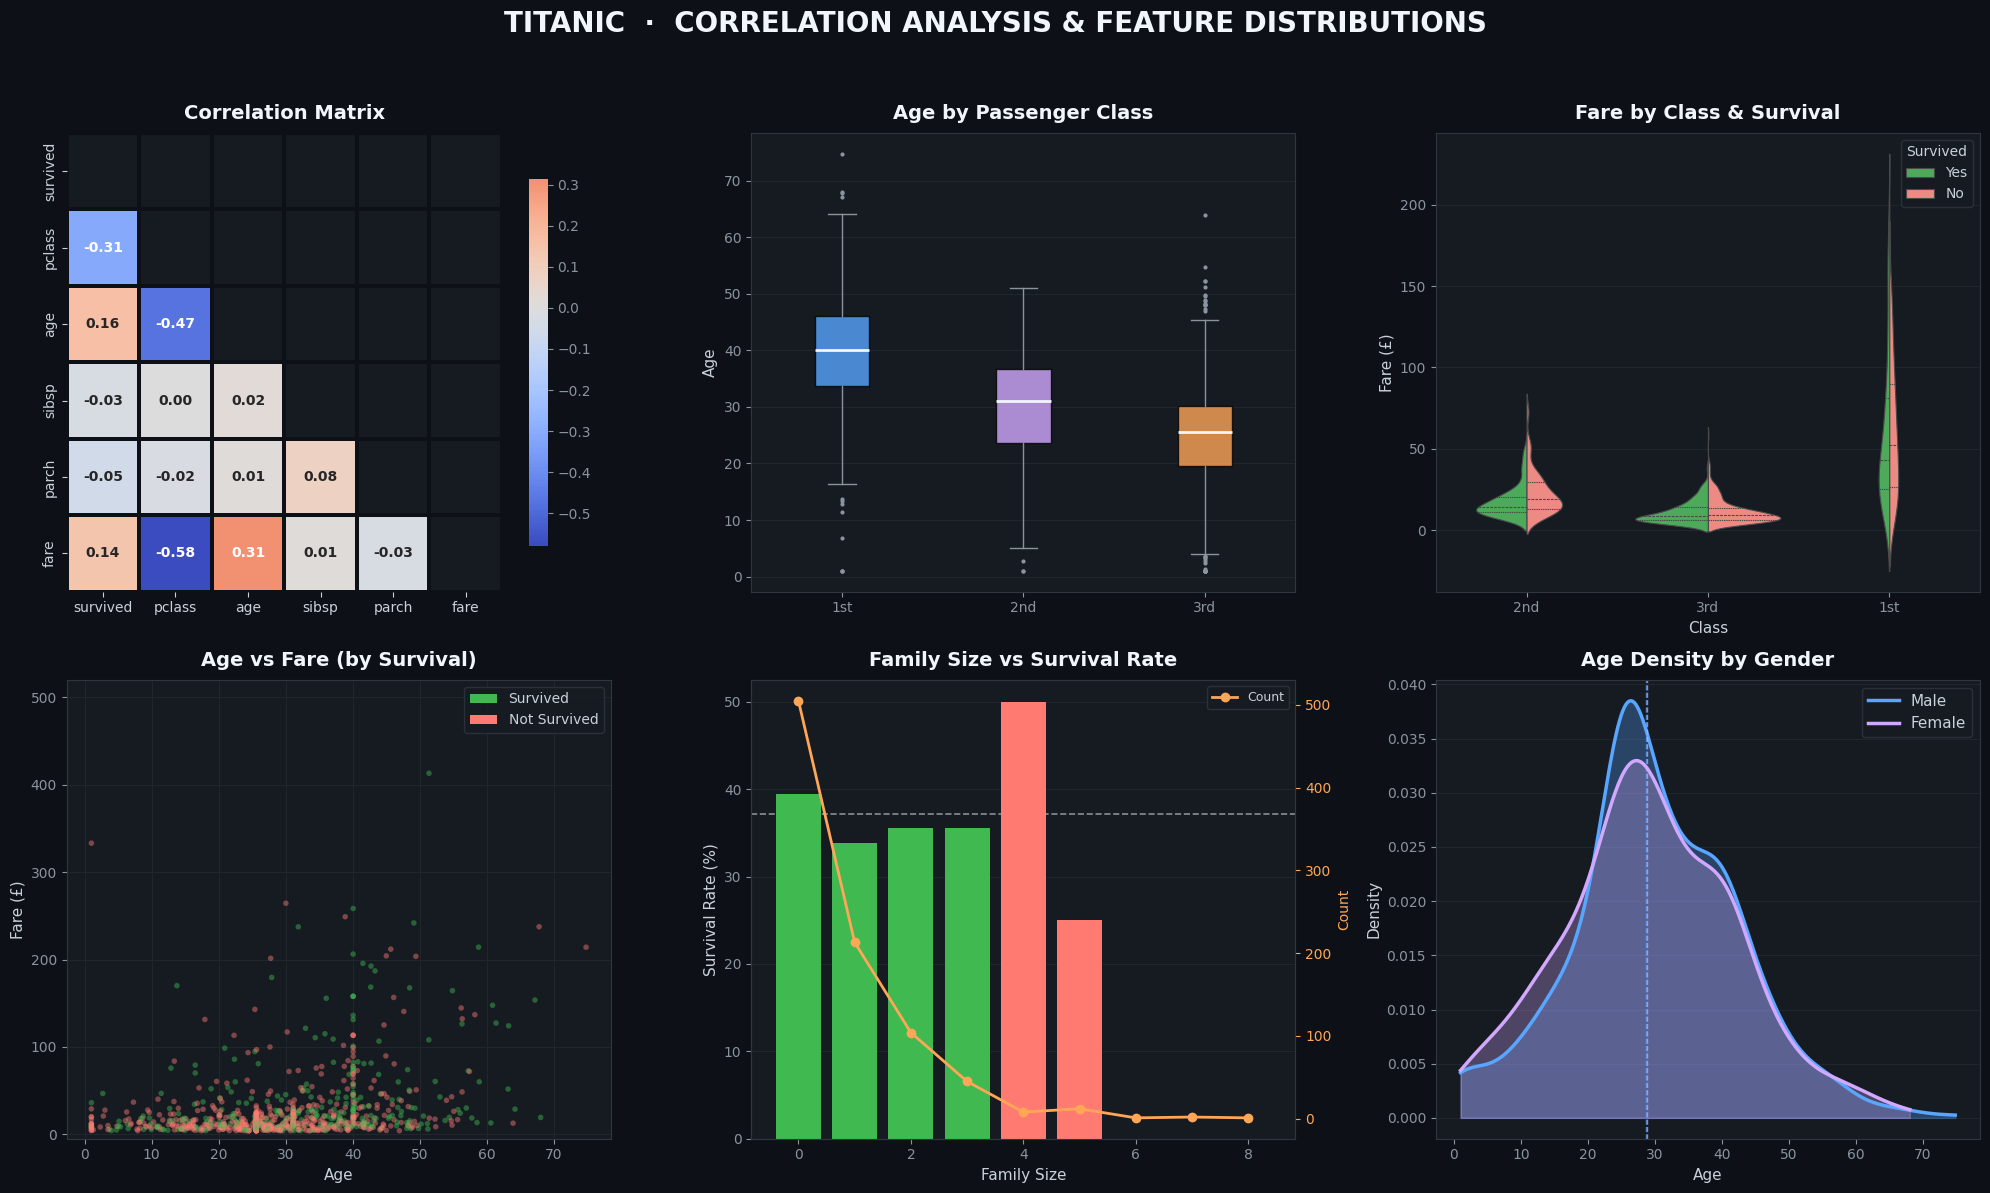

In [12]:
def kde(data,n=300):
    d=data.dropna(); xs=np.linspace(d.min(),d.max(),n)
    return xs, gaussian_kde(d)(xs)

fig2,axes2 = plt.subplots(2,3,figsize=(20,12),facecolor='#0d1117')
fig2.suptitle('TITANIC  ·  CORRELATION ANALYSIS & FEATURE DISTRIBUTIONS',
              fontsize=20,fontweight='bold',color='#f0f6fc',y=0.99)
fig2.patch.set_facecolor('#0d1117')

# Correlation heatmap
ax=axes2[0,0]
num_cols=['survived','pclass','age','sibsp','parch','fare']
corr=df[num_cols].corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',center=0,
            linewidths=1.5,linecolor='#0d1117',annot_kws={'size':10,'weight':'bold'},
            ax=ax,cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.tick_params(colors='#c9d1d9'); ax.set_facecolor('#161b22')

# Boxplot age by class
ax=axes2[0,1]; ax.set_facecolor('#161b22')
data_bc=[df[df['pclass']==c]['age'].dropna().values for c in [1,2,3]]
bp=ax.boxplot(data_bc,patch_artist=True,
    medianprops=dict(color='#f0f6fc',linewidth=2),
    whiskerprops=dict(color='#8b949e'),capprops=dict(color='#8b949e'),
    flierprops=dict(marker='o',markerfacecolor='#8b949e',markersize=3,linestyle='none',markeredgewidth=0))
for patch,color in zip(bp['boxes'],[ACCENT,PURPLE,ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(['1st','2nd','3rd'])
ax.set_title('Age by Passenger Class',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.set_ylabel('Age',fontsize=11); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# Violin fare by class & survival
ax=axes2[0,2]; ax.set_facecolor('#161b22')
df_v=df[df['fare']<200].copy()
df_v['Survived']=df_v['survived'].map({0:'No',1:'Yes'})
df_v['Class']=df_v['pclass'].map({1:'1st',2:'2nd',3:'3rd'})
sns.violinplot(data=df_v,x='Class',y='fare',hue='Survived',
               palette={'No':RED,'Yes':GREEN},split=True,inner='quart',ax=ax,linewidth=0.8)
ax.set_title('Fare by Class & Survival',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.set_xlabel('Class',fontsize=11); ax.set_ylabel('Fare (£)',fontsize=11)
ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# Scatter age vs fare
ax=axes2[1,0]; ax.set_facecolor('#161b22')
c_s=[GREEN if s==1 else RED for s in df['survived']]
ax.scatter(df['age'],df['fare'],c=c_s,alpha=0.45,s=16,edgecolors='none')
ax.set_title('Age vs Fare (by Survival)',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.set_xlabel('Age',fontsize=11); ax.set_ylabel('Fare (£)',fontsize=11); ax.set_ylim(-5,520)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GREEN,label='Survived'),Patch(facecolor=RED,label='Not Survived')],fontsize=10)
ax.yaxis.grid(True,zorder=0); ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# Family size vs survival
ax=axes2[1,1]; ax.set_facecolor('#161b22')
fam_surv=df.groupby('family_size')['survived'].mean()*100
fam_cnt=df.groupby('family_size').size()
bc2=[GREEN if i<=3 else RED for i in fam_surv.index]
ax.bar(fam_surv.index,fam_surv.values,color=bc2,edgecolor='none',zorder=3)
ax2b=ax.twinx()
ax2b.plot(fam_cnt.index,fam_cnt.values,color=ORANGE,marker='o',lw=2,ms=6,label='Count')
ax2b.set_ylabel('Count',fontsize=10,color=ORANGE); ax2b.tick_params(axis='y',colors=ORANGE)
ax.axhline(survival_rate,color='white',ls='--',lw=1.2,alpha=0.5)
ax.set_title('Family Size vs Survival Rate',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.set_xlabel('Family Size',fontsize=11); ax.set_ylabel('Survival Rate (%)',fontsize=11)
ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True); ax2b.legend(fontsize=9,loc='upper right')

# KDE age by gender
ax=axes2[1,2]; ax.set_facecolor('#161b22')
for g,c,l in [('male',ACCENT,'Male'),('female',PURPLE,'Female')]:
    d=df[df['sex']==g]['age'].dropna()
    xs,ys=kde(d)
    ax.fill_between(xs,ys,alpha=0.3,color=c)
    ax.plot(xs,ys,color=c,lw=2.5,label=l)
    ax.axvline(d.median(),color=c,ls='--',lw=1,alpha=0.7)
ax.set_title('Age Density by Gender',fontsize=14,fontweight='bold',pad=10,color='#f0f6fc')
ax.set_xlabel('Age',fontsize=11); ax.set_ylabel('Density',fontsize=11)
ax.legend(fontsize=11); ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## 6. Key Findings

| Finding | Detail |
|---|---|
| **Overall Survival Rate** | ~37% of passengers survived |
| **Gender Effect** | Females survived at ~78% vs Males at ~18% ("women first") |
| **Class Effect** | 1st class ~64% survival, 3rd class ~24% |
| **Age** | Children had the highest survival rates |
| **Fare Correlation** | Higher fare → higher survival (correlated with class) |
| **Family Size** | Solo travelers and small families (2–3) survived best |
| **Embarkation** | Southampton had the most passengers (~72%) |
